# Onboarding Checklist Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/onboarding-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/onboarding-agent/demo.ipynb)

A **multi-step agent** that walks a new hire's onboarding checklist, resolves step dependencies, and
flags overdue/blocked steps — so ramp-up doesn't quietly stretch to 3 months.

**What this notebook covers:**
1. A role-aware checklist with step dependencies
2. The agent loop: resolve dependency → check deadline → classify status
3. Running it on a new hire 34 days in, partly onboarded
4. Visualizing checklist status by phase
5. A "Try Your Own" section for a different hire/date


## Step 1: Why this needs to be multi-step, not one-shot

A single "is this done?" check per item misses two things: (1) some steps **depend on** earlier
ones (you can't get tool access before IT setup), and (2) some steps are **role-specific** (sales
playbook doesn't apply to engineers). The agent has to walk the whole checklist, resolve
dependencies in order, and only then classify each step's status against today's date.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import date
from typing import Dict, List, Optional, Set


@dataclass
class ChecklistItem:
    item_id: str
    phase: str
    title: str
    expected_by_day: int
    depends_on: Optional[str] = None
    roles: Optional[List[str]] = None


@dataclass
class NewHire:
    name: str
    role: str
    start_date: date
    completed_ids: Set[str] = field(default_factory=set)


@dataclass
class StepStatus:
    item: ChecklistItem
    status: str
    nudge: str = ""


DEFAULT_CHECKLIST: List[ChecklistItem] = [
    ChecklistItem("it_setup", "Day 1", "Provision laptop, email, and SSO access", 0),
    ChecklistItem("hr_paperwork", "Day 1", "Complete HR paperwork and tax forms", 0),
    ChecklistItem("welcome_meeting", "Day 1", "Welcome meeting with manager", 0),
    ChecklistItem("tool_access", "Week 1", "Get access to Slack, Jira/Linear, and internal wiki", 1, depends_on="it_setup"),
    ChecklistItem("team_intro", "Week 1", "1:1 intros with each teammate", 3),
    ChecklistItem("first_task", "Week 1", "Assigned first small task/ticket", 5, depends_on="tool_access"),
    ChecklistItem("codebase_walkthrough", "Week 1", "Codebase/architecture walkthrough", 5, roles=["Engineer", "Data Scientist"]),
    ChecklistItem("sales_playbook", "Week 1", "Sales playbook and CRM training", 5, roles=["Sales"]),
    ChecklistItem("30_day_review", "Month 1", "30-day check-in with manager", 30),
    ChecklistItem("first_project", "Month 1", "Ship first real project/deliverable", 30, depends_on="first_task"),
    ChecklistItem("60_day_review", "Month 3", "60-day check-in with manager", 60),
    ChecklistItem("90_day_review", "Month 3", "90-day performance review", 90, depends_on="60_day_review"),
]


def _rule_based_nudge(item: ChecklistItem, status: str) -> str:
    if status == "overdue":
        return f"Overdue: '{item.title}' was expected by day {item.expected_by_day}. Follow up today."
    if status == "due_soon":
        return f"Due soon: '{item.title}' expected by day {item.expected_by_day}."
    if status == "blocked":
        return f"Blocked: '{item.title}' depends on an incomplete step."
    return ""


def evaluate_onboarding(hire: NewHire, checklist=None, today=None) -> List[StepStatus]:
    checklist = checklist or DEFAULT_CHECKLIST
    today = today or date.today()
    days_elapsed = (today - hire.start_date).days
    applicable = [item for item in checklist if item.roles is None or hire.role in item.roles]
    results: List[StepStatus] = []

    for item in applicable:
        if item.item_id in hire.completed_ids:
            results.append(StepStatus(item, "completed"))
            continue
        if item.depends_on and item.depends_on not in hire.completed_ids:
            if any(i.item_id == item.depends_on for i in applicable):
                status = "blocked"
                results.append(StepStatus(item, status, _rule_based_nudge(item, status)))
                continue
        if days_elapsed > item.expected_by_day:
            status = "overdue"
        elif item.expected_by_day - days_elapsed <= 3:
            status = "due_soon"
        else:
            status = "upcoming"
        nudge = _rule_based_nudge(item, status) if status in ("overdue", "due_soon") else ""
        results.append(StepStatus(item, status, nudge))
    return results


def progress_summary(statuses: List[StepStatus]) -> Dict[str, int]:
    summary = {"completed": 0, "overdue": 0, "due_soon": 0, "blocked": 0, "upcoming": 0}
    for s in statuses:
        summary[s.status] += 1
    return summary

print("Onboarding agent loaded.")

Onboarding agent loaded.


## Step 2: Evaluate a new hire 34 days in

Alex started June 1, only Day-1 steps are done, and it's now day 34 — well past several deadlines.


In [2]:
hire = NewHire(
    name="Alex Kim",
    role="Engineer",
    start_date=date(2026, 6, 1),
    completed_ids={"it_setup", "hr_paperwork", "welcome_meeting"},
)
today = date(2026, 7, 5)

statuses = evaluate_onboarding(hire, today=today)
for s in statuses:
    marker = {"completed": "✅", "overdue": "🔴", "blocked": "⛔", "due_soon": "🟡", "upcoming": "⚪"}[s.status]
    print(f"{marker} {s.status:10s} | {s.item.phase:8s} | {s.item.title}")
    if s.nudge:
        print(f"      -> {s.nudge}")

print()
print("Summary:", progress_summary(statuses))

✅ completed  | Day 1    | Provision laptop, email, and SSO access
✅ completed  | Day 1    | Complete HR paperwork and tax forms
✅ completed  | Day 1    | Welcome meeting with manager
🔴 overdue    | Week 1   | Get access to Slack, Jira/Linear, and internal wiki
      -> Overdue: 'Get access to Slack, Jira/Linear, and internal wiki' was expected by day 1. Follow up today.
🔴 overdue    | Week 1   | 1:1 intros with each teammate
      -> Overdue: '1:1 intros with each teammate' was expected by day 3. Follow up today.
⛔ blocked    | Week 1   | Assigned first small task/ticket
      -> Blocked: 'Assigned first small task/ticket' depends on an incomplete step.
🔴 overdue    | Week 1   | Codebase/architecture walkthrough
      -> Overdue: 'Codebase/architecture walkthrough' was expected by day 5. Follow up today.
🔴 overdue    | Month 1  | 30-day check-in with manager
      -> Overdue: '30-day check-in with manager' was expected by day 30. Follow up today.
⛔ blocked    | Month 1  | Ship first re

## Visualization: checklist status by phase

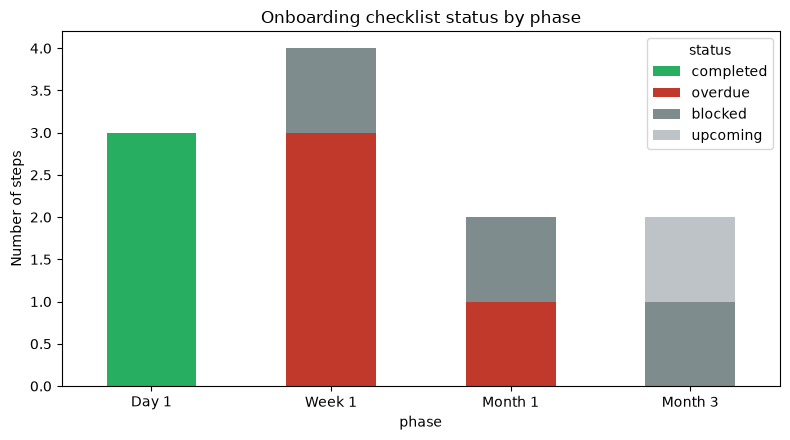

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame([{"phase": s.item.phase, "status": s.status} for s in statuses])
pivot = df.groupby(["phase", "status"]).size().unstack(fill_value=0)
phase_order = ["Day 1", "Week 1", "Month 1", "Month 3"]
pivot = pivot.reindex(phase_order)

status_colors = {"completed": "#27AE60", "overdue": "#C0392B", "blocked": "#7F8C8D", "due_soon": "#F1C40F", "upcoming": "#BDC3C7"}
present_statuses = [s for s in status_colors if s in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot[present_statuses].plot(kind="bar", stacked=True, ax=ax, color=[status_colors[s] for s in present_statuses])
ax.set_ylabel("Number of steps")
ax.set_title("Onboarding checklist status by phase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("onboarding_status.png", dpi=150)
plt.show()

## Summary

At day 34, Alex has 3 completed steps but 4 overdue and 3 blocked (blocked steps cascade — tool
access being late blocks the first task, which blocks the first project). This is exactly the
pattern that stretches ramp-up to 3 months: one missed Week-1 step quietly blocks everything after
it. Surfacing the dependency chain, not just a flat checklist, is what makes the nudge actionable.


## Try Your Own

Uncomment and edit to evaluate a different hire or date:

In [4]:
# my_hire = NewHire(name="Jordan Lee", role="Sales", start_date=date(2026, 7, 1), completed_ids={"it_setup"})
# my_statuses = evaluate_onboarding(my_hire, today=date(2026, 7, 10))
# for s in my_statuses:
#     print(s.status, s.item.title, s.nudge)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI and live checkboxes:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` for Claude-written nudge messages instead of the rule-based defaults.
